In [82]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix , roc_auc_score ,roc_curve

In [2]:
df =pd.read_csv('/Users/sanjayduduka/Desktop/NLP/train.txt',sep=";",header=None, names = ['text','emotion'])
df.head()

,text,emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [3]:
df.isnull().sum().sum()

np.int64(0)

In [4]:
df.duplicated().sum()

np.int64(1)

In [5]:
df.drop_duplicates(inplace=True)

Converting to lowercase

In [6]:
df['text']=df['text'].apply(lambda x: x.lower())

In [7]:
unique_emotions=df['emotion'].unique()
unique_emotions

array(['sadness', 'anger', 'love', 'surprise', 'fear', 'joy'],
      dtype=object)

In [8]:
emotion_numbers={}
i=0 
for emo in unique_emotions:
    emotion_numbers[emo] =i
    i+=1
df['emotion']=df['emotion'].map(emotion_numbers)

In [9]:
df

,text,emotion
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,1
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,1
...,...,...
15995,i just had a very brief time in the beanbag an...,0
15996,i am now turning and i feel pathetic that i am...,0
15997,i feel strong and good overall,5
15998,i feel like this was such a rude comment and i...,1


Remove Punctuations

In [10]:
stopwords = set(stopwords.words('english'))
ps=PorterStemmer()

In [11]:
def preprocess_text(text):

    text=text.lower()
    text=re.sub(r'\d+',' ' ,text)

    text = text.translate(
        str.maketrans(' ',' ' , string.punctuation))

    text = re.sub(r'\s+',' ' ,text)

    tokens= text.split() 

    tokens = [word for word in tokens if word not in stopwords and len(word) >1]

    tokens = [ps.stem(word) for word in tokens]
    return " ".join(tokens)


In [12]:
df["clean_text"] = df["text"].apply(preprocess_text)
print(df['clean_text'].sample(10))

10984    got sexi latex outfit lucki chair made feel na...
12698                   follow feel repress year month day
10057    becom comfort time feel discont pursu thing lo...
8383                               feel stupid thoughtless
8010     feel like miss everi singl holiday last year h...
12611    think left teach feel littl frighten thought f...
7241     kinda like saw hannah montana sinc broke nick ...
12823    wonder genentech feel hostil takeov global par...
4850                                       went feel shaki
3124                  feel scare dont know student teacher
Name: clean_text, dtype: object


In [13]:
X = df["clean_text"]

y = df["emotion"]

In [14]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
X_test.shape

(3200,)

In [16]:
X_train.shape

(12799,)

In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)
X_train_tfidf=tfidf.fit_transform(X_train)
X_test_tfidf=tfidf.transform(X_test)

In [34]:
models = {
    
    "Logistic Regression": LogisticRegression(
        C=10,
        max_iter=5000,
        solver='liblinear',
        random_state=42
    ),

    "Linear SVC": LinearSVC(
        C=1.5,
        max_iter=5000,
        random_state=42
    ),

    "Multinomial NB": MultinomialNB(
        alpha=0.1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=5000,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=5000,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=8,
        random_state=42
    )
}


In [35]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

for name, model in models.items():

    model.fit(X_train_tfidf, y_train)

    y_pred = model.predict(X_test_tfidf)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted'),
        "Recall": recall_score(y_test, y_pred, average='weighted'),
        "F1 Score": f1_score(y_test, y_pred, average='weighted')
    })

import pandas as pd

results_df = pd.DataFrame(results)
results_df.sort_values(by="F1 Score", ascending=False)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.015355 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 31678
[LightGBM] [Info] Number of data points in the train set: 12799, number of used features: 1326
[LightGBM] [Info] Start training from score -1.236719
[LightGBM] [Info] Start training from score -2.007043
[LightGBM] [Info] Start training from score -2.548368
[LightGBM] [Info] Start training from score -3.312937
[LightGBM] [Info] Start training from score -2.103400
[LightGBM] [Info] Start training from score -1.082876
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning]

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Model,Accuracy,Precision,Recall,F1 Score
3,XGBoost,0.879687,0.879169,0.879687,0.878942
1,Linear SVC,0.879375,0.877942,0.879375,0.877506
0,Logistic Regression,0.877188,0.876374,0.877188,0.874290
4,LightGBM,0.839375,0.839294,0.839375,0.836600
2,Multinomial NB,0.793438,0.807069,0.793438,0.779617


In [38]:

from sklearn.model_selection import RandomizedSearchCV

xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

param_dist = {
    'n_estimators': [300, 500, 700, 1000],
    'max_depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.3, 0.5]
}

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=30,
    scoring='f1_weighted',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_tfidf, y_train)

print(random_search.best_params_)
print(random_search.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.01, max_depth=6, min_child_weight=5, n_estimators=1000, subsample=0.7; total time= 1.2min
[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.01, max_depth=6, min_child_weight=5, n_estimators=1000, subsample=0.7; total time= 1.2min
[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.01, max_depth=6, min_child_weight=5, n_estimators=1000, subsample=0.7; total time= 1.2min
[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.01, max_depth=6, min_child_weight=5, n_estimators=1000, subsample=0.7; total time= 1.2min
[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.01, max_depth=6, min_child_weight=5, n_estimators=1000, subsample=0.7; total time= 1.2min
[CV] END colsample_bytree=0.9, gamma=0.1, learning_rate=0.03, max_depth=10, min_child_weight=3, n_estimators=500, subsample=0.9; total time= 1.7min
[CV] END colsample_bytree=0.9, gamma=0.1, learning

In [75]:
best_model= random_search.best_estimator_
best_model

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0.5,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=1, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=1000, n_jobs=None,
              num_parallel_tree=None, ...)

In [39]:

y_pred = best_model.predict(X_test_tfidf)
y_pred

array([0, 5, 0, ..., 5, 5, 0])

In [40]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy :", accuracy)

Accuracy : 0.8821875


In [41]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.95      0.91      0.93       950
           1       0.89      0.87      0.88       439
           2       0.82      0.74      0.78       303
           3       0.74      0.75      0.75       106
           4       0.85      0.86      0.86       375
           5       0.86      0.92      0.89      1027

    accuracy                           0.88      3200
   macro avg       0.85      0.84      0.85      3200
weighted avg       0.88      0.88      0.88      3200



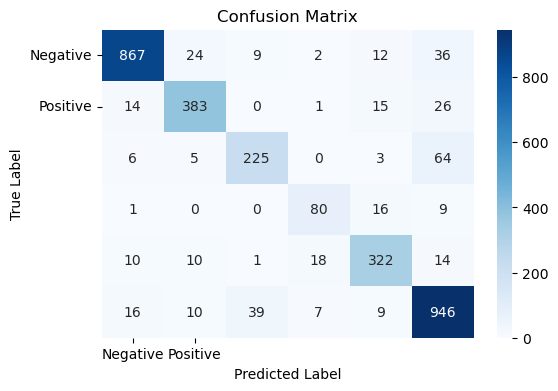

In [83]:

y_pred = best_model.predict(X_test_tfidf)


cm = confusion_matrix(y_test, y_pred)


plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive']
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

models = {
    'XGBoost': best_model,
}

for name, model in models.items():

    probs = model.predict_proba(X_test_tfidf)[:,1]

    y_true_binary = (y_test == 1).astype(int)
    fpr, tpr, _ = roc_curve(y_true_binary, probs)

    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'{name} (AUC={roc_auc:.3f})')

plt.plot([0,1],[0,1],'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend()

plt.show()

ValueError: multiclass format is not supported

<Figure size 800x600 with 0 Axes>

In [58]:
new_text = "I feel very lonely and hopeless"

clean_text = preprocess_text(new_text)

vector = tfidf.transform([clean_text])

prediction = model.predict(vector)

print(prediction)

[0]


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [55]:
unique_emotions

array(['sadness', 'anger', 'love', 'surprise', 'fear', 'joy'],
      dtype=object)